In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [32]:
df = pd.read_excel("Task2_Employee_Performance_500_Rows.xlsx")

print(df.head())
print(df.info())

   employee_id  work_experience_years  monthly_working_hours  \
0          201                     12                    176   
1          202                      6                    152   
2          203                      5                    186   
3          204                     11                    171   
4          205                      7                    147   

   projects_completed  avg_task_rating  overtime_hours  leave_days_taken  \
0                   5              4.4               9                 2   
1                   3              4.5               2                 2   
2                   4              4.2               5                 1   
3                   4              2.8              12                 2   
4                   1              3.6               0                 4   

  department performance_outcome  
0         IT            Achieved  
1    Finance            Achieved  
2         IT            Achieved  
3  Marketing      

In [33]:
print(df.columns)

Index(['employee_id', 'work_experience_years', 'monthly_working_hours',
       'projects_completed', 'avg_task_rating', 'overtime_hours',
       'leave_days_taken', 'department', 'performance_outcome'],
      dtype='object')


In [34]:
# Assume target column name = 'Performance' (adjust if different)

print(df["performance_outcome"].value_counts())


performance_outcome
Not Achieved    400
Achieved        100
Name: count, dtype: int64


Index(['employee_id', 'work_experience_years', 'monthly_working_hours',
       'projects_completed', 'avg_task_rating', 'overtime_hours',
       'leave_days_taken', 'department', 'performance_outcome'],
      dtype='object')


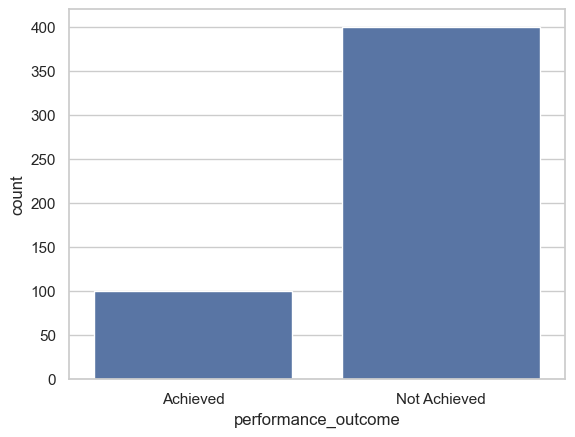

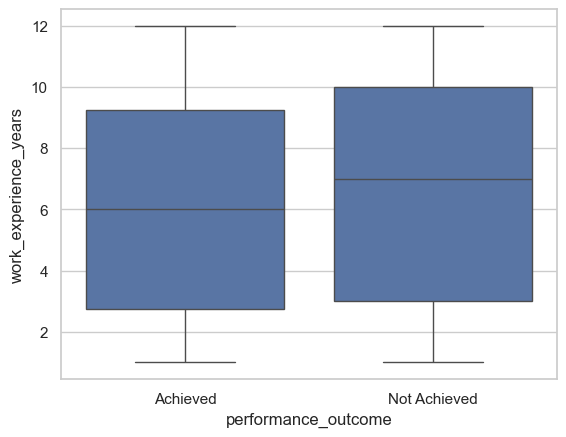

In [35]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

# Countplot
sns.countplot(x="performance_outcome", data=df)
plt.show()

# Boxplot
sns.boxplot(x="performance_outcome", y="work_experience_years", data=df)
plt.show()



In [36]:
# Features & target
X = df.drop("performance_outcome", axis=1)
y = df["performance_outcome"]

In [39]:
# Remove ID column
X = X.drop("employee_id", axis=1)

# Convert categorical column to numeric
X = pd.get_dummies(X, drop_first=True)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [42]:
y_pred = model.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Achieved       1.00      1.00      1.00        18
Not Achieved       1.00      1.00      1.00        82

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



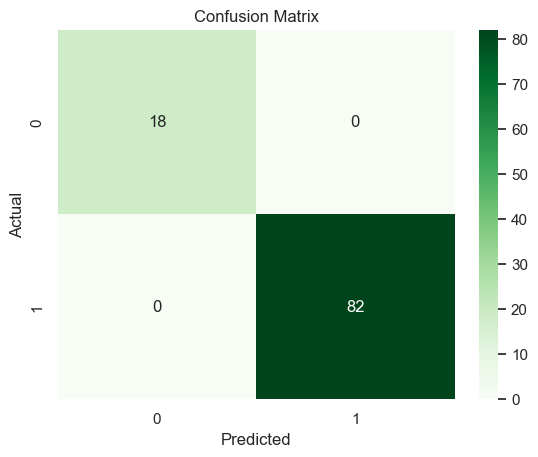

In [44]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

                  Feature  Importance
5        leave_days_taken    0.496126
3         avg_task_rating    0.287877
4          overtime_hours    0.215996
2      projects_completed    0.000000
1   monthly_working_hours    0.000000
0   work_experience_years    0.000000
6           department_HR    0.000000
7           department_IT    0.000000
8    department_Marketing    0.000000
9        department_Sales    0.000000
10     department_Support    0.000000


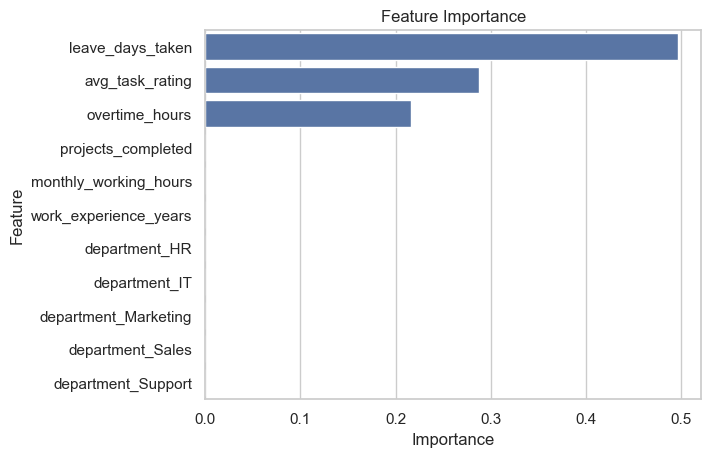

In [45]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)

sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Feature Importance")
plt.show()